# Drug Response Prediction with Predicted Profiles

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr,ttest_ind
from sklearn.metrics import mean_squared_error
import numpy as np

In [17]:
# Get the project root directory
from pathlib import Path
import sys

project_root = Path.cwd()
sys.path.append(str(project_root.parent))

from notebook_imports import *

In [18]:
# Set project directories using configuration
home_dir = str(config.PROJECT_ROOT)
data_dir = str(config.DATA_DIR)
resources_dir = str(config.RESOURCES_DIR)
results_dir = str(config.RESULTS_04_DIR)
figures_dir = str(config.FIGURES_04_DIR)

In [19]:
# Prediction evaluation function. Either pearsonr or spearmanr
evaluation_function = pearsonr

In [20]:
# Color palettes
pre_post_lfc_palette = {
    'Grey': '#808080',       # Standard grey
    'Red': '#FF0000',        # Bright red
    'Dark Red': '#8B0000'    # Dark red
}
pre_post_lfc_palette = list(pre_post_lfc_palette.values())
    

In [21]:
def compute_pearson(predictions, groupby=['model', 'test_set','train_set', 'split']):

    pearson_results = predictions.groupby(groupby).apply(
        lambda group: evaluation_function(group['true'], group['pred'])[0]
    ).fillna(0)
    pearson_p_value_results = predictions.groupby(groupby).apply(
        lambda group: evaluation_function(group['true'], group['pred'])[1]
    ).fillna(1)

    pearson_results = pd.merge(pearson_results.reset_index(), pearson_p_value_results.reset_index(), on=groupby).rename(columns={'0_x': 'pearson', '0_y': 'p-value'})

    pearson_results = pearson_results.reset_index(drop=True).replace({'post_treatment': 'Post', 'pre_treatment': 'Pre'}).replace({'observed':'Observed',
                                                                                                                            'GEARS_noreg':'GEARS\nOptimized'})

    from statsmodels.stats.multitest import multipletests

    pearson_results['adjusted_p'] = multipletests(pearson_results['p-value'], alpha=0.05, method='fdr_bh')[1]
    pearson_results['sig'] = np.where(pearson_results['adjusted_p'] < 0.05, '*', '')

    if 'test_set' in groupby:
        pearson_results['test_set'] = pd.Categorical(pearson_results['test_set'], categories=['Observed','CPA', 'GEARS','GEARS\nOptimized','scFoundation', 'Average effect', 'No effect', 'GEARS\nEnd-to-End'], ordered=True)

    return pearson_results


def compute_mse(predictions, groupby=['model', 'test_set','train_set', 'split']):

    mse_results = predictions.groupby(groupby).apply(
        lambda group: mean_squared_error(group['true'], group['pred']))

    mse_results = mse_results.reset_index().replace({'post_treatment': 'Post', 'pre_treatment': 'Pre'}).replace({'observed':'Observed',
                                                                                                                            'GEARS_noreg':'GEARS\nOptimized'})

    mse_results = mse_results.rename(columns={0:'mse'})                                                                                                                  

    if 'test_set' in groupby:
        mse_results['test_set'] = pd.Categorical(mse_results['test_set'], categories=['Observed','CPA', 'GEARS','GEARS\nOptimized','scFoundation', 'Average effect', 'No effect', 'GEARS\nEnd-to-End'], ordered=True)

    return mse_results

In [22]:
def plot_sensitvity_predictions(pearson_results, metric='pearson',plot_text=True, plot_end_to_end=True, plot_legend=True):

    if plot_end_to_end == True:
        fig, axes = plt.subplots(1, 4, figsize=(18, 7), dpi=300, gridspec_kw={'width_ratios': [3,12,12,1]}, sharey=False)
    else:
        fig, axes = plt.subplots(1, 3, figsize=(17, 7), dpi=300, gridspec_kw={'width_ratios': [3,12,12]}, sharey=False)
        axes = [axes]

    # Calculate observed baselines
    pre_observed = pearson_results[(pearson_results['trained_on'] == 'Observed')&(pearson_results['test_set'] == 'Observed') & (pearson_results['model'] == 'Pre')][metric].mean()
    post_observed = pearson_results[(pearson_results['trained_on'] == 'Observed')&(pearson_results['test_set'] == 'Observed') & (pearson_results['model'] == 'Post')][metric].mean()
    lfc_observed = pearson_results[(pearson_results['trained_on'] == 'Observed')&(pearson_results['test_set'] == 'Observed') & (pearson_results['model'] == 'LFC')][metric].mean()
    print(f'Pre: {pre_observed}, Post: {post_observed}, LFC: {lfc_observed}')

    # --- LEFT SUBPLOT: bar_data ---
    bar_data = pearson_results[~pearson_results['test_set'].isin(['GEARS\nEnd-to-End'])].copy()
    bar0_data = bar_data[(bar_data['trained_on'] == 'Observed')&(bar_data['test_set'].isin(['Observed']))].copy()
    bar1_data = bar_data[bar_data['trained_on'] == 'Observed'].copy()
    bar2_data = bar_data[(bar_data['trained_on'] == 'Predicted')&(bar_data['test_set']!='Observed')].copy()
    bar3_data = bar_data[(bar_data['trained_on'] == 'Predicted')&(bar_data['test_set']=='Observed')].copy()


    bar0_data['test_set'] = pd.Categorical(
        bar0_data['test_set'],
        categories=['Observed'],
        ordered=True
    )
    bar0_data['model'] = pd.Categorical(bar0_data['model'], categories=['Pre', 'Post', 'LFC'], ordered=True)

    bar1_data['test_set'] = pd.Categorical(
        bar1_data['test_set'],
        categories=['GEARS', 'GEARS\nOptimized', 'CPA', 'scFoundation', 'Average effect', 'No effect'],
        ordered=True
    )
    bar1_data['model'] = pd.Categorical(bar1_data['model'], categories=['Post', 'LFC'], ordered=True)

    bar2_data['test_set'] = pd.Categorical(
        bar2_data['test_set'],
        categories=['GEARS', 'GEARS\nOptimized', 'CPA', 'scFoundation', 'Average effect', 'No effect'],
        ordered=True
    )
    bar2_data['model'] = pd.Categorical(bar2_data['model'], categories=['Post', 'LFC'], ordered=True)

    bar3_data['train_set'] = pd.Categorical(
        bar3_data['train_set'],
        categories=['GEARS', 'GEARS\nOptimized', 'CPA', 'scFoundation', 'Average effect', 'No effect'],
        ordered=True
    )
    bar3_data['model'] = pd.Categorical(bar3_data['model'], categories=['Post', 'LFC'], ordered=True)

    bar_datasets = [bar0_data, bar1_data, bar2_data]

    for i, bar_data in enumerate(bar_datasets):
        sns.barplot(
            data=bar_data,
            x='train_set' if i == 3 else 'test_set',
            hue='model',
            y=metric,
            edgecolor='black',
            palette=[pre_post_lfc_palette[1], pre_post_lfc_palette[2]] if i > 0 else [pre_post_lfc_palette[0], pre_post_lfc_palette[1], pre_post_lfc_palette[2]] ,
            ax=axes[i]
        )

        sns.despine(ax=axes[i], offset=10, trim=False)
        
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')
        axes[i].set_xticklabels(axes[i].get_xticklabels(), fontsize=22, rotation=60, ha='right',rotation_mode='anchor')
        axes[i].yaxis.set_tick_params(labelsize=16)

        if plot_legend:
            if i == 0:
                axes[i].legend(title='', fontsize=14, loc='upper right', bbox_to_anchor=(1, 1.25), frameon=False)
            #     axes[i].legend(title='', fontsize=18, loc='upper left', bbox_to_anchor=(-0.5, 1.15), frameon=False, ncol=3)
            else:
                axes[i].legend_.remove()
        else:
            axes[i].legend_.remove()

        if plot_text == True:
            axes[-1].text(x=0.7, y=pre_observed*0.99, s='Pre', color=pre_post_lfc_palette[0], fontsize=24, ha='left')
            if post_observed > lfc_observed:
                axes[-1].text(x=0.7, y=post_observed*1, s='Post', color=pre_post_lfc_palette[1], fontsize=24, ha='left')
                axes[-1].text(x=0.7, y=lfc_observed*0.9, s='LFC', color=pre_post_lfc_palette[2], fontsize=24, ha='left')
            else:
                axes[-1].text(x=0.7, y=post_observed*0.9, s='Post', color=pre_post_lfc_palette[1], fontsize=24, ha='left')
                axes[-1].text(x=0.7, y=lfc_observed*1.05, s='LFC', color=pre_post_lfc_palette[2], fontsize=24, ha='left')


    # --- RIGHT SUBPLOT: bar2_data ---
    if plot_end_to_end:
        bar4_data = pearson_results[pearson_results['test_set'] == 'GEARS\nEnd-to-End'].copy()
        bar4_data['test_set'] = pd.Categorical(bar4_data['test_set'], categories=['GEARS\nEnd-to-End'], ordered=True)
        bar4_data['model'] = pd.Categorical(bar4_data['model'], categories=['Embedding'], ordered=True)

        sns.barplot(
            data=bar4_data,
            x='test_set',
            y=metric,
            hue='model',
            edgecolor='black',
            palette=['black'],
            ax=axes[-1],
            legend=False
        )
        
        sns.despine(ax=axes[-1], offset=10, trim=False)
        axes[-1].set_xticklabels(['GEARS\nEnd-to-End'], fontsize=22, rotation=60, ha='right',rotation_mode='anchor')


    for i, ax in enumerate(axes):
        axes[i].set_xlabel('')
        if metric == 'roc_auc':
            axes[i].set_ylim(0.4,lfc_observed*1.1)
        elif metric == 'mse':
            axes[i].set_ylim(0.01,pre_observed*1.25)
            # axes[i].set_yscale('log')
        else:
            axes[i].set_ylim(0,lfc_observed*1.1)
        axes[i].axhline(pre_observed, ls='--', color=pre_post_lfc_palette[0])
        axes[i].axhline(post_observed, ls='--', color=pre_post_lfc_palette[1])
        axes[i].axhline(lfc_observed, ls='--', color=pre_post_lfc_palette[2])
        if i > 0:
            axes[i].set_ylabel('')
            # Remove all y-axis elements
            axes[i].yaxis.set_visible(False)
            # Remove left spine (optional, depending on style)
            axes[i].spines['left'].set_visible(False)
            # Optional: tighter layout
            axes[i].tick_params(axis='y', which='both', left=False, labelleft=False)

    # Shared y-axis label
    if metric == 'pearson':
        metric_label = r'Pearson r  $\rightarrow$'
    elif metric == 'top10_overlap':
        metric_label = r'Top-10 Retrieval Accuracy (%) $\rightarrow$'
    elif metric == 'roc_auc':
        metric_label = r'ROC-AUC $\rightarrow$'
    elif metric == 'mse':
        metric_label = r'MSE $\leftarrow$'
    else:
        metric_label = metric

    axes[0].set_ylabel(metric_label, fontsize=25)
    import matplotlib as mpl
    BR = r'\\' if mpl.rcParams['text.usetex'] else '\n'

    # axes[0].set_title(fr"Trained on $\mathbf{{observed}}${BR}Tested on $\mathbf{{observed}}$", fontsize=18)
    fig.text(0.52, 0.97, 
             fr"Drug Response Prediction{BR}with $\mathbf{{Predicted}}$ Profiles", 
             ha='center', va='bottom', fontsize=22, fontweight='bold')
    
    axes[1].set_title(fr"(trained on $\mathbf{{measured}}$ profiles)", fontsize=22, pad=20)
    axes[2].set_title(fr"(trained on $\mathbf{{predicted}}$ profiles)", fontsize=22, pad=20)

    fig.tight_layout(pad=1.5)
    fig.subplots_adjust(top=0.88)  # Make room for main title
    return fig, axes

In [23]:
predictions_AUC = pd.read_csv(os.path.join(results_dir, 'sciplex_regression_predictions_CV_twostep_AUC.csv'), index_col=0).reset_index().drop_duplicates().set_index('index')
selftrained_predictions_AUC = pd.read_csv(os.path.join(results_dir, 'sciplex_regression_predictions_selftrained_CV_twostep_AUC.csv'), index_col=0).reset_index().drop_duplicates().set_index('index')

In [24]:
end_to_end_predictions  = []
for cl in ['mcf7', 'a549', 'k562']:
    outcome_path = os.path.join(data_dir, f'GEARS_end_to_end/sciplex{cl}')
    subfolders = [ f.path for f in os.scandir(outcome_path) if f.is_dir() ]
    newest_subfolders = [x for x in subfolders if '2025-06-20' in x]
    print(subfolders)
    for i in range(1, 6):
        outcomes = pd.read_csv(os.path.join(outcome_path, newest_subfolders[0], f'raw_y_pred_no_pretrain_fold{i}_1_sciplex{cl}.csv'))
        outcomes = outcomes.assign(cell_line=cl).assign(split=i)
        end_to_end_predictions.append(outcomes)

end_to_end_predictions = pd.concat(end_to_end_predictions, ignore_index=True).assign(test_set='GEARS\nEnd-to-End',train_set='observed', model='Embedding').rename(columns={'truth':'true'})

sciplex_pearson_results = compute_pearson(predictions_AUC)
sciplex_mse_results = compute_mse(predictions_AUC)
selftrained_sciplex_pearson_results = compute_pearson(selftrained_predictions_AUC)
selftrained_sciplex_mse_results = compute_mse(selftrained_predictions_AUC)
end_to_end_pearson = compute_pearson(end_to_end_predictions)
end_to_end_mse = compute_mse(end_to_end_predictions)

sciplex_pearson_results = pd.concat([sciplex_pearson_results.assign(trained_on='Observed'),selftrained_sciplex_pearson_results.assign(trained_on='Predicted'), end_to_end_pearson.assign(trained_on='End-to-end')], ignore_index=True)
sciplex_mse_results = pd.concat([sciplex_mse_results.assign(trained_on='Observed'),selftrained_sciplex_mse_results.assign(trained_on='Predicted'), end_to_end_mse.assign(trained_on='End-to-end')], ignore_index=True)

['u:\\nbrouwer1\\perturbation_modeling\\drug-response-prediction\\data\\GEARS_end_to_end/sciplexmcf7\\2025-06-20_09-58-14']
['u:\\nbrouwer1\\perturbation_modeling\\drug-response-prediction\\data\\GEARS_end_to_end/sciplexa549\\2025-06-20_09-54-17']
['u:\\nbrouwer1\\perturbation_modeling\\drug-response-prediction\\data\\GEARS_end_to_end/sciplexk562\\2025-06-20_09-54-16']


C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_17188\2839024774.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  lambda group: evaluation_function(group['true'], group['pred'])[0]
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_17188\2839024774.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pearson_results = predictions.groupby(groupby).apply(
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_17188\2839024774.py:7: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  lambda group: evaluation_function(group['true'], group['pred'])[1]
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_17188\2839024774.p

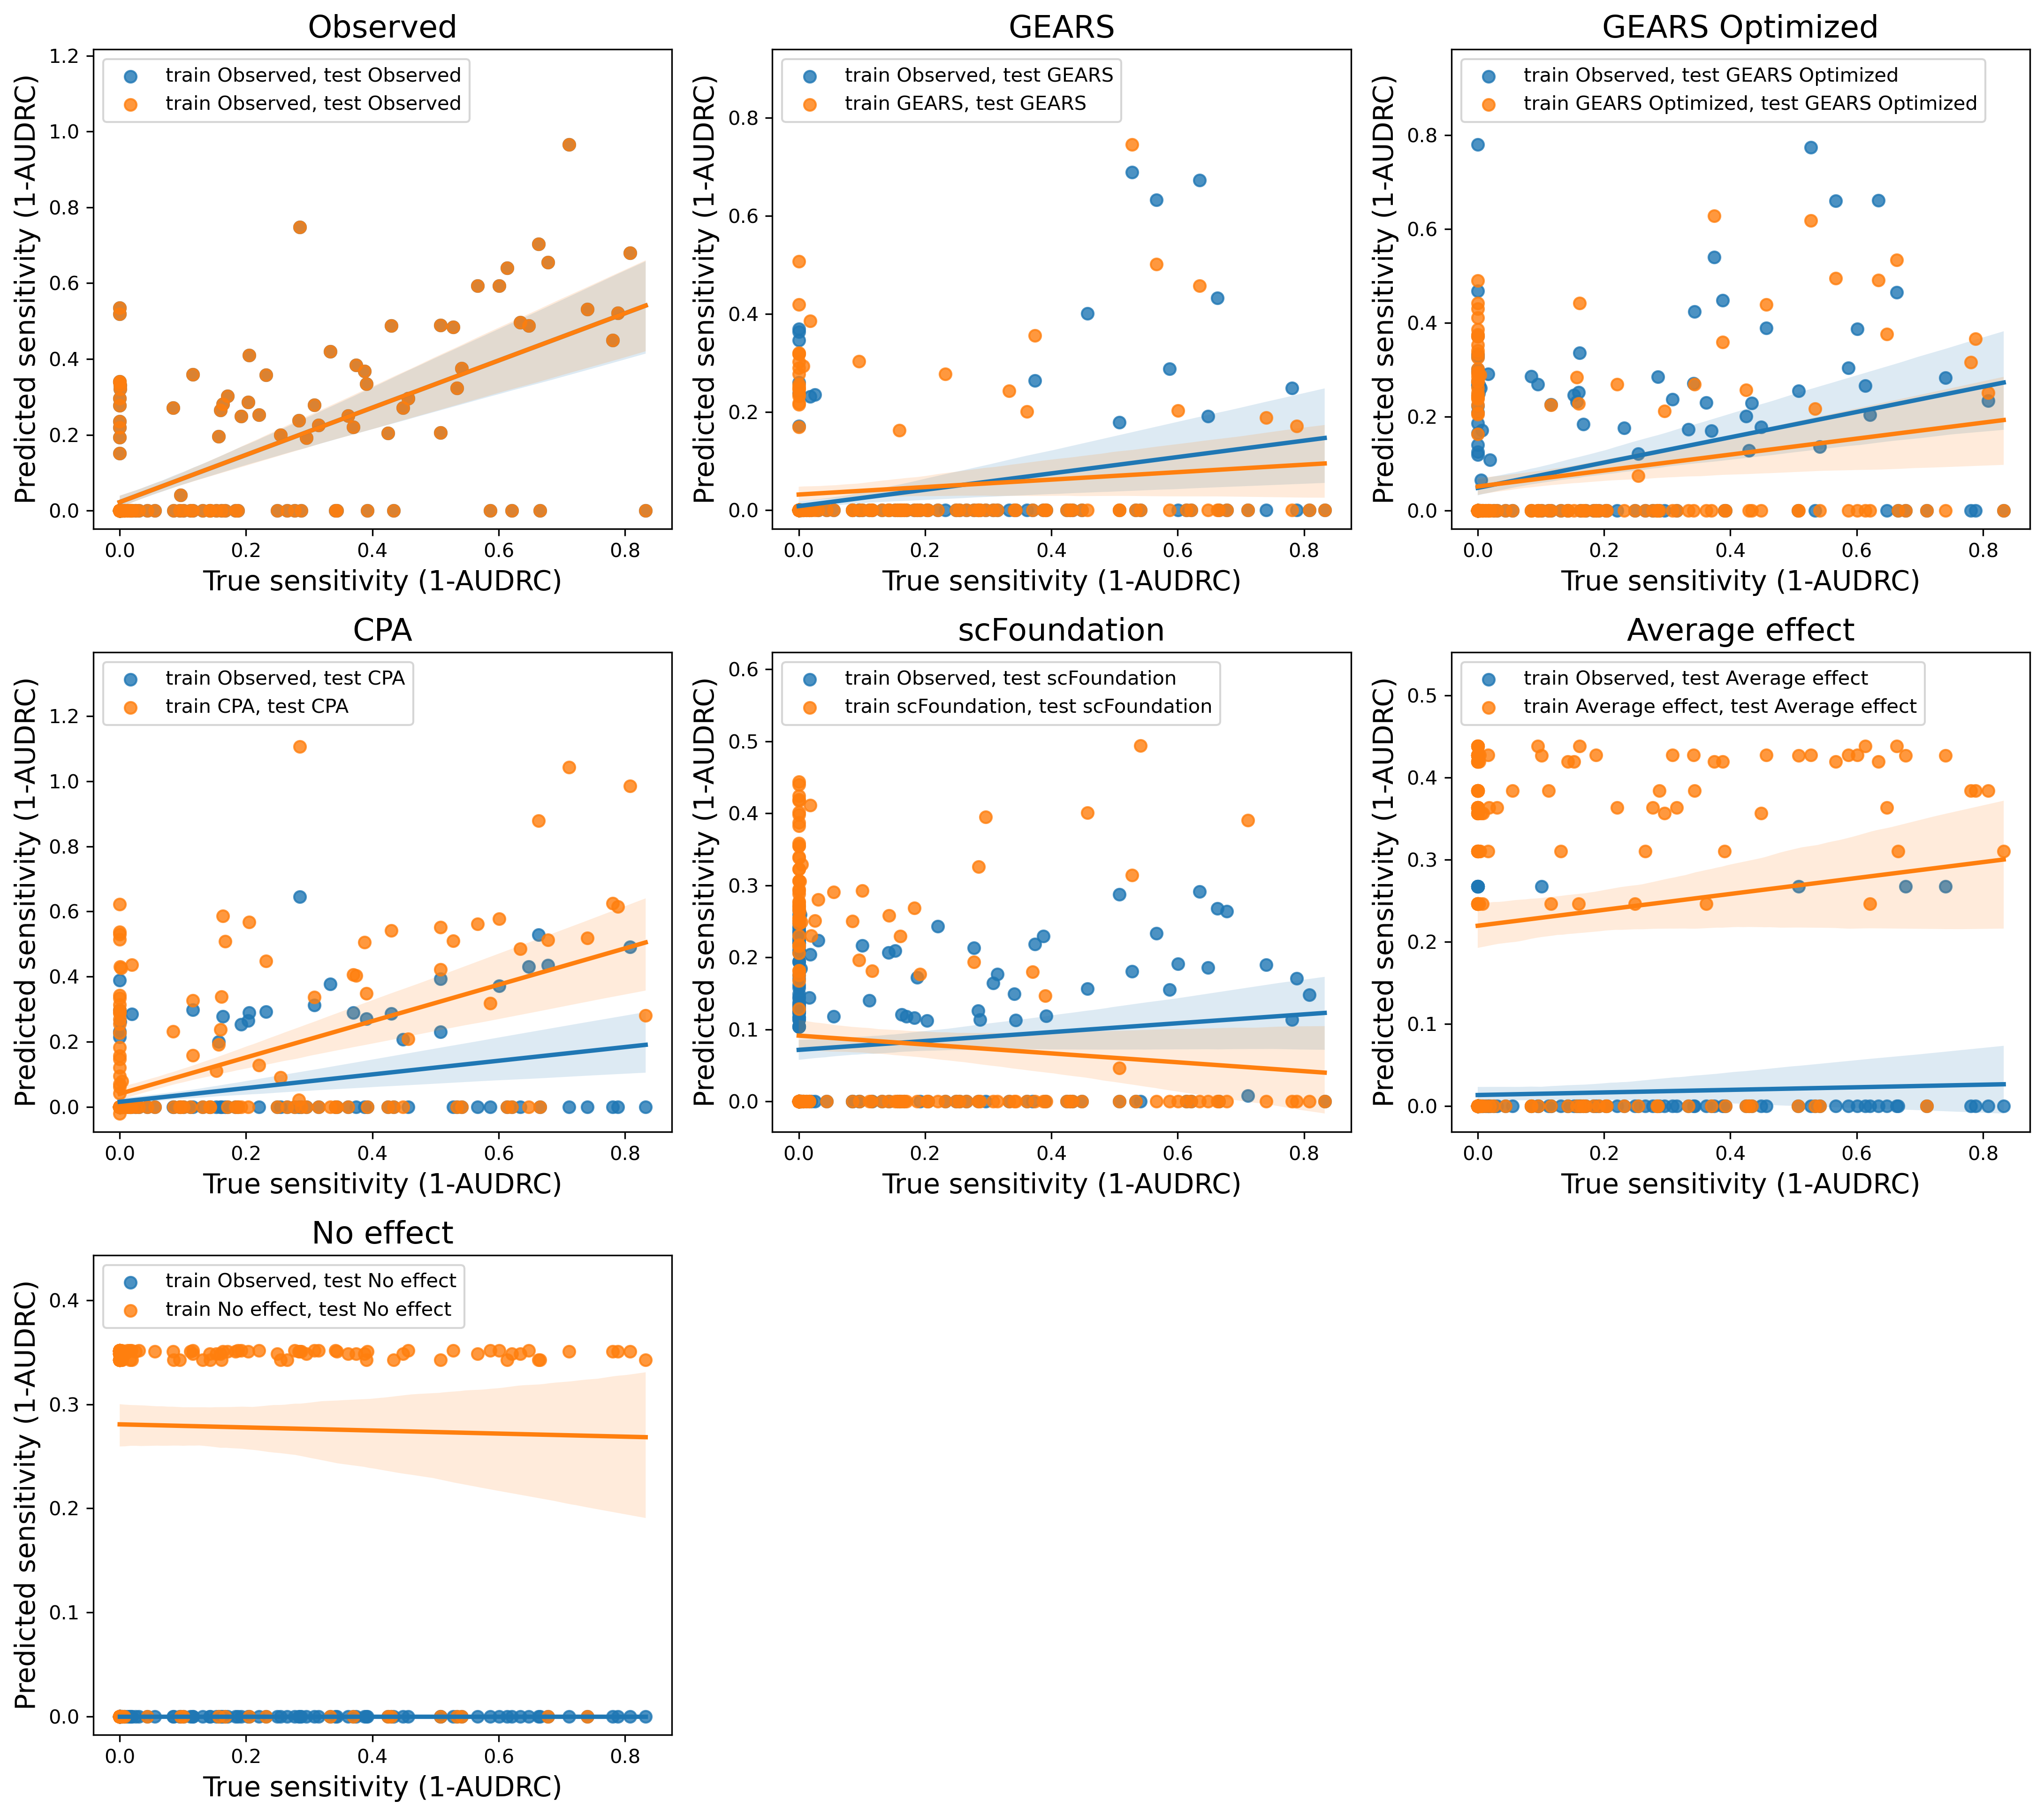

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Unique training sets
# train_sets = selftrained_predictions_AUC['train_set'].unique().tolist()
train_sets = ['observed','GEARS', 'GEARS_noreg', 'CPA', 'scFoundation', 'Average effect', 'No effect']


# Mapping for display names
mapping = {
    'observed': 'Observed',
    'baseline': 'Average effect',
    'GEARS_noreg': 'GEARS Optimized',
    'No effect': 'No effect'
}

# Create figure and axes
fig, axes = plt.subplots(3, 3, figsize=(15, 13), dpi=300)
axes = axes.flatten()
# If there is only one subplot, make axes a list for consistent indexing
if len(train_sets) == 1:
    axes = [axes]

for i, m in enumerate(train_sets):
    ax = axes[i]
    name = mapping.get(m, m)
    sns.regplot(
        data=predictions_AUC.query(f'test_set == "{m}" and train_set == "observed" and model == "LFC"'),
        x='true', y='pred', label=f'train Observed, test {name}', ax=ax
    )

    sns.regplot(
        data=selftrained_predictions_AUC.query(f'test_set == "{m}" and train_set == "{m}" and model == "LFC"'),
        x='true', y='pred', label=f'train {name}, test {name}', ax=ax
    )
 

    # Adjust ylim (+0.5 to the current max)
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax *1.2)

    # Style
    ax.legend(loc='upper left', fontsize=10)
    ax.set_xlabel('True sensitivity (1-AUDRC)', fontsize=14)
    ax.set_ylabel('Predicted sensitivity (1-AUDRC)', fontsize=14)
    ax.set_title(name, fontsize=16)

# Hide unused subplot (8th cell)
if len(train_sets) < len(axes):
    for j in range(len(train_sets), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

fig.savefig(os.path.join(figures_dir, 'regression_plots.pdf'), bbox_inches='tight')


Pre: 0.14920717063358385, Post: 0.7068229482147717, LFC: 0.7007283439750525


C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_17188\3105303686.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), fontsize=22, rotation=60, ha='right',rotation_mode='anchor')
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_17188\3105303686.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), fontsize=22, rotation=60, ha='right',rotation_mode='anchor')
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_17188\3105303686.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), fontsize=22, rotation=60, ha='right',rotation_mode='anchor')
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_17188\3105

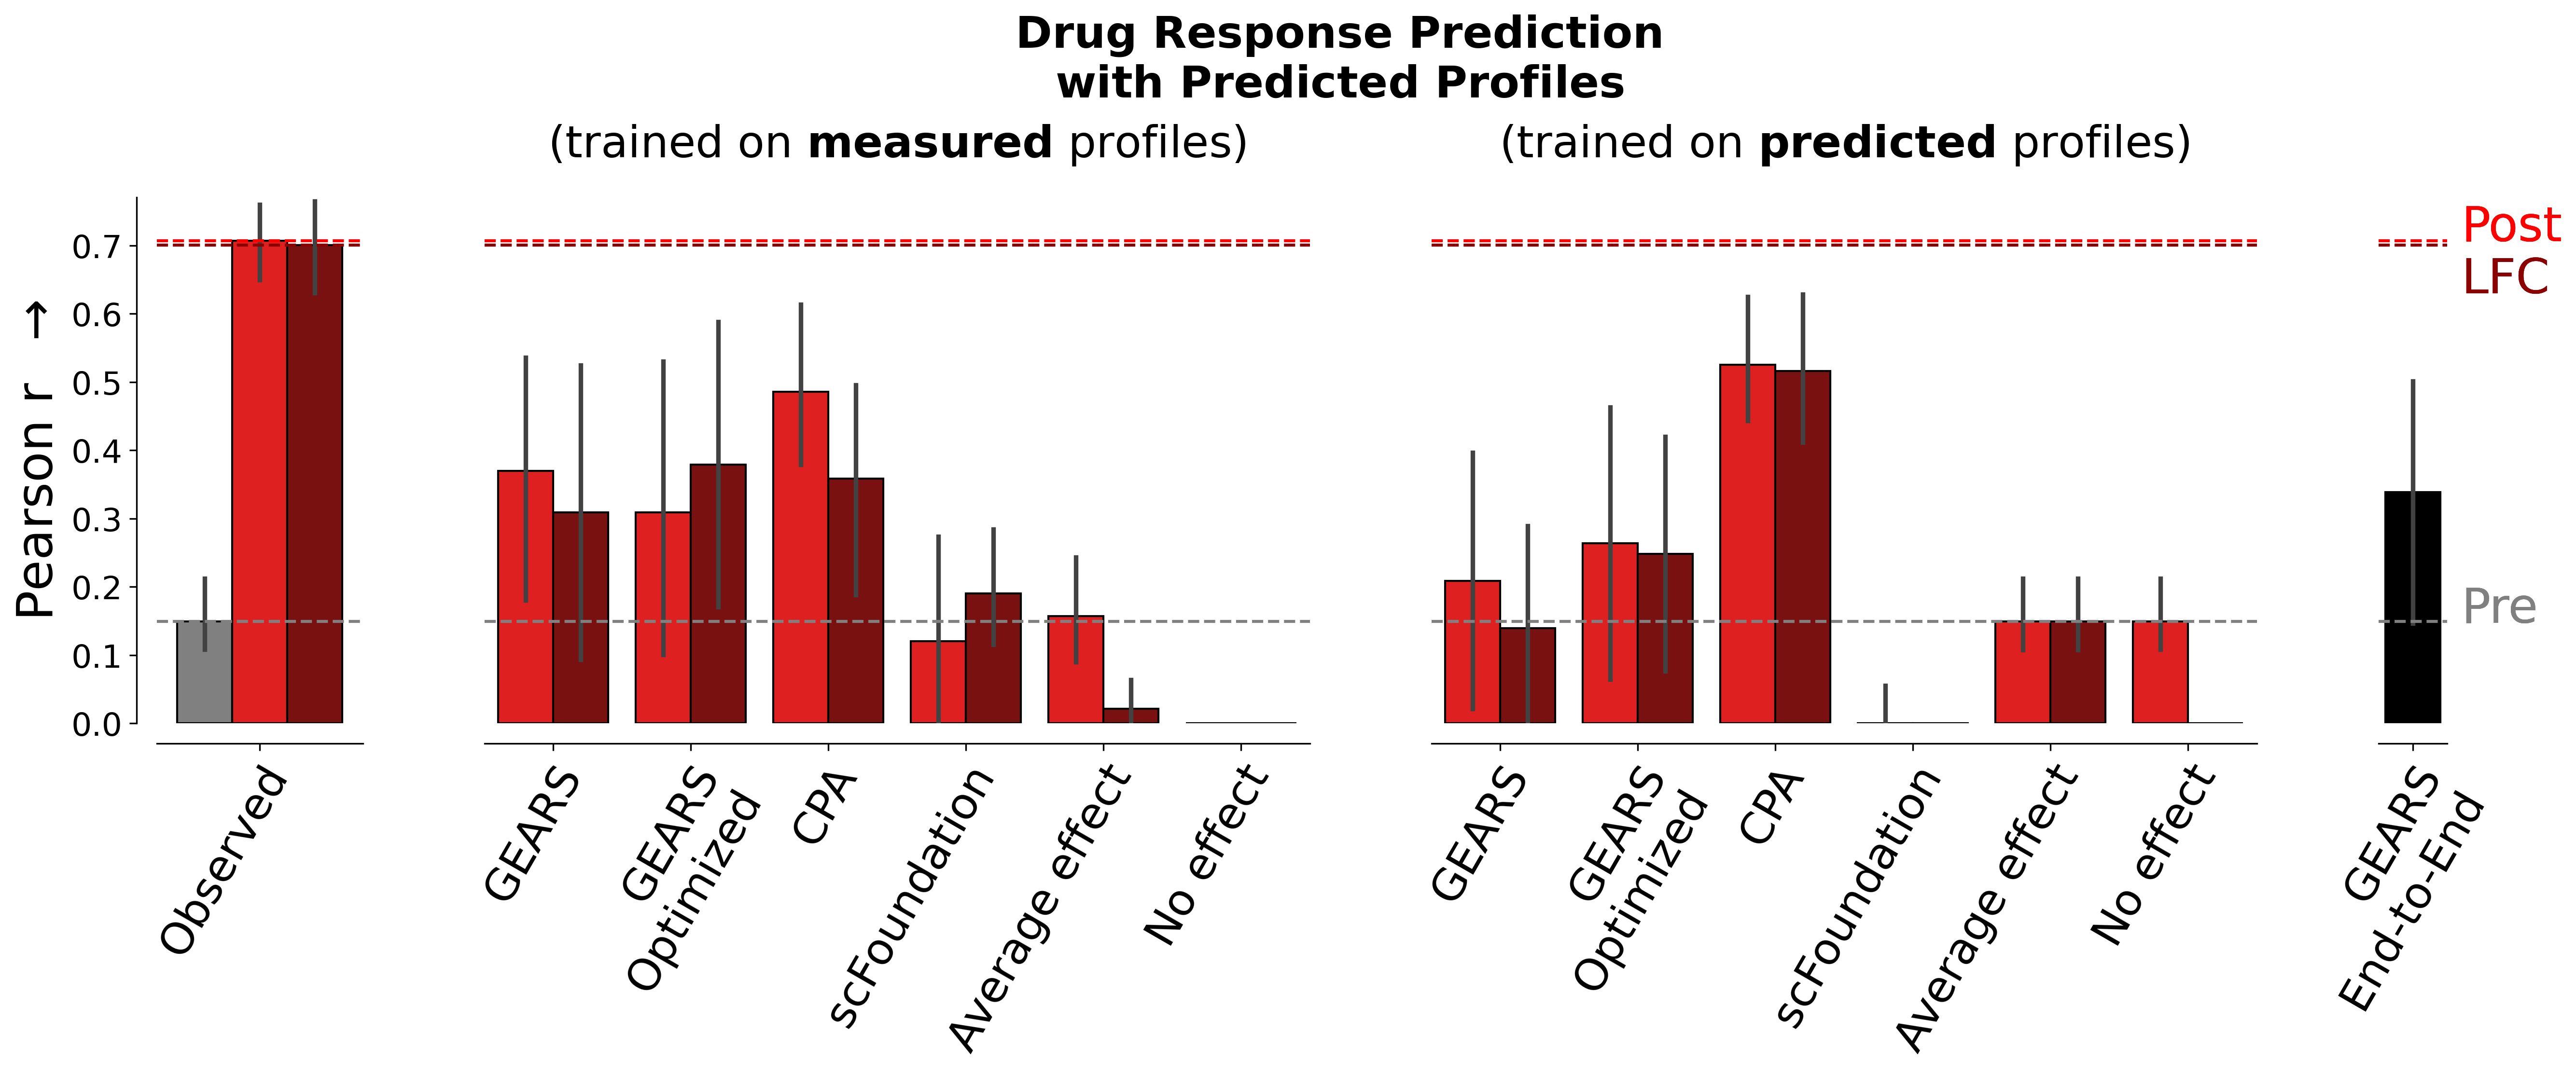

In [26]:
fig, ax= plot_sensitvity_predictions(sciplex_pearson_results, metric='pearson', plot_text=True, plot_end_to_end=True, plot_legend=False)
fig.savefig(os.path.join(figures_dir,'sciplex_predictions_with_predicted_profiles.pdf'), bbox_inches='tight')

plt.show()

Pre: 0.08162191305314292, Post: 0.02224375944511246, LFC: 0.023623633175935254


C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_17188\3105303686.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), fontsize=22, rotation=60, ha='right',rotation_mode='anchor')
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_17188\3105303686.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), fontsize=22, rotation=60, ha='right',rotation_mode='anchor')
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_17188\3105303686.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), fontsize=22, rotation=60, ha='right',rotation_mode='anchor')
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_17188\3105

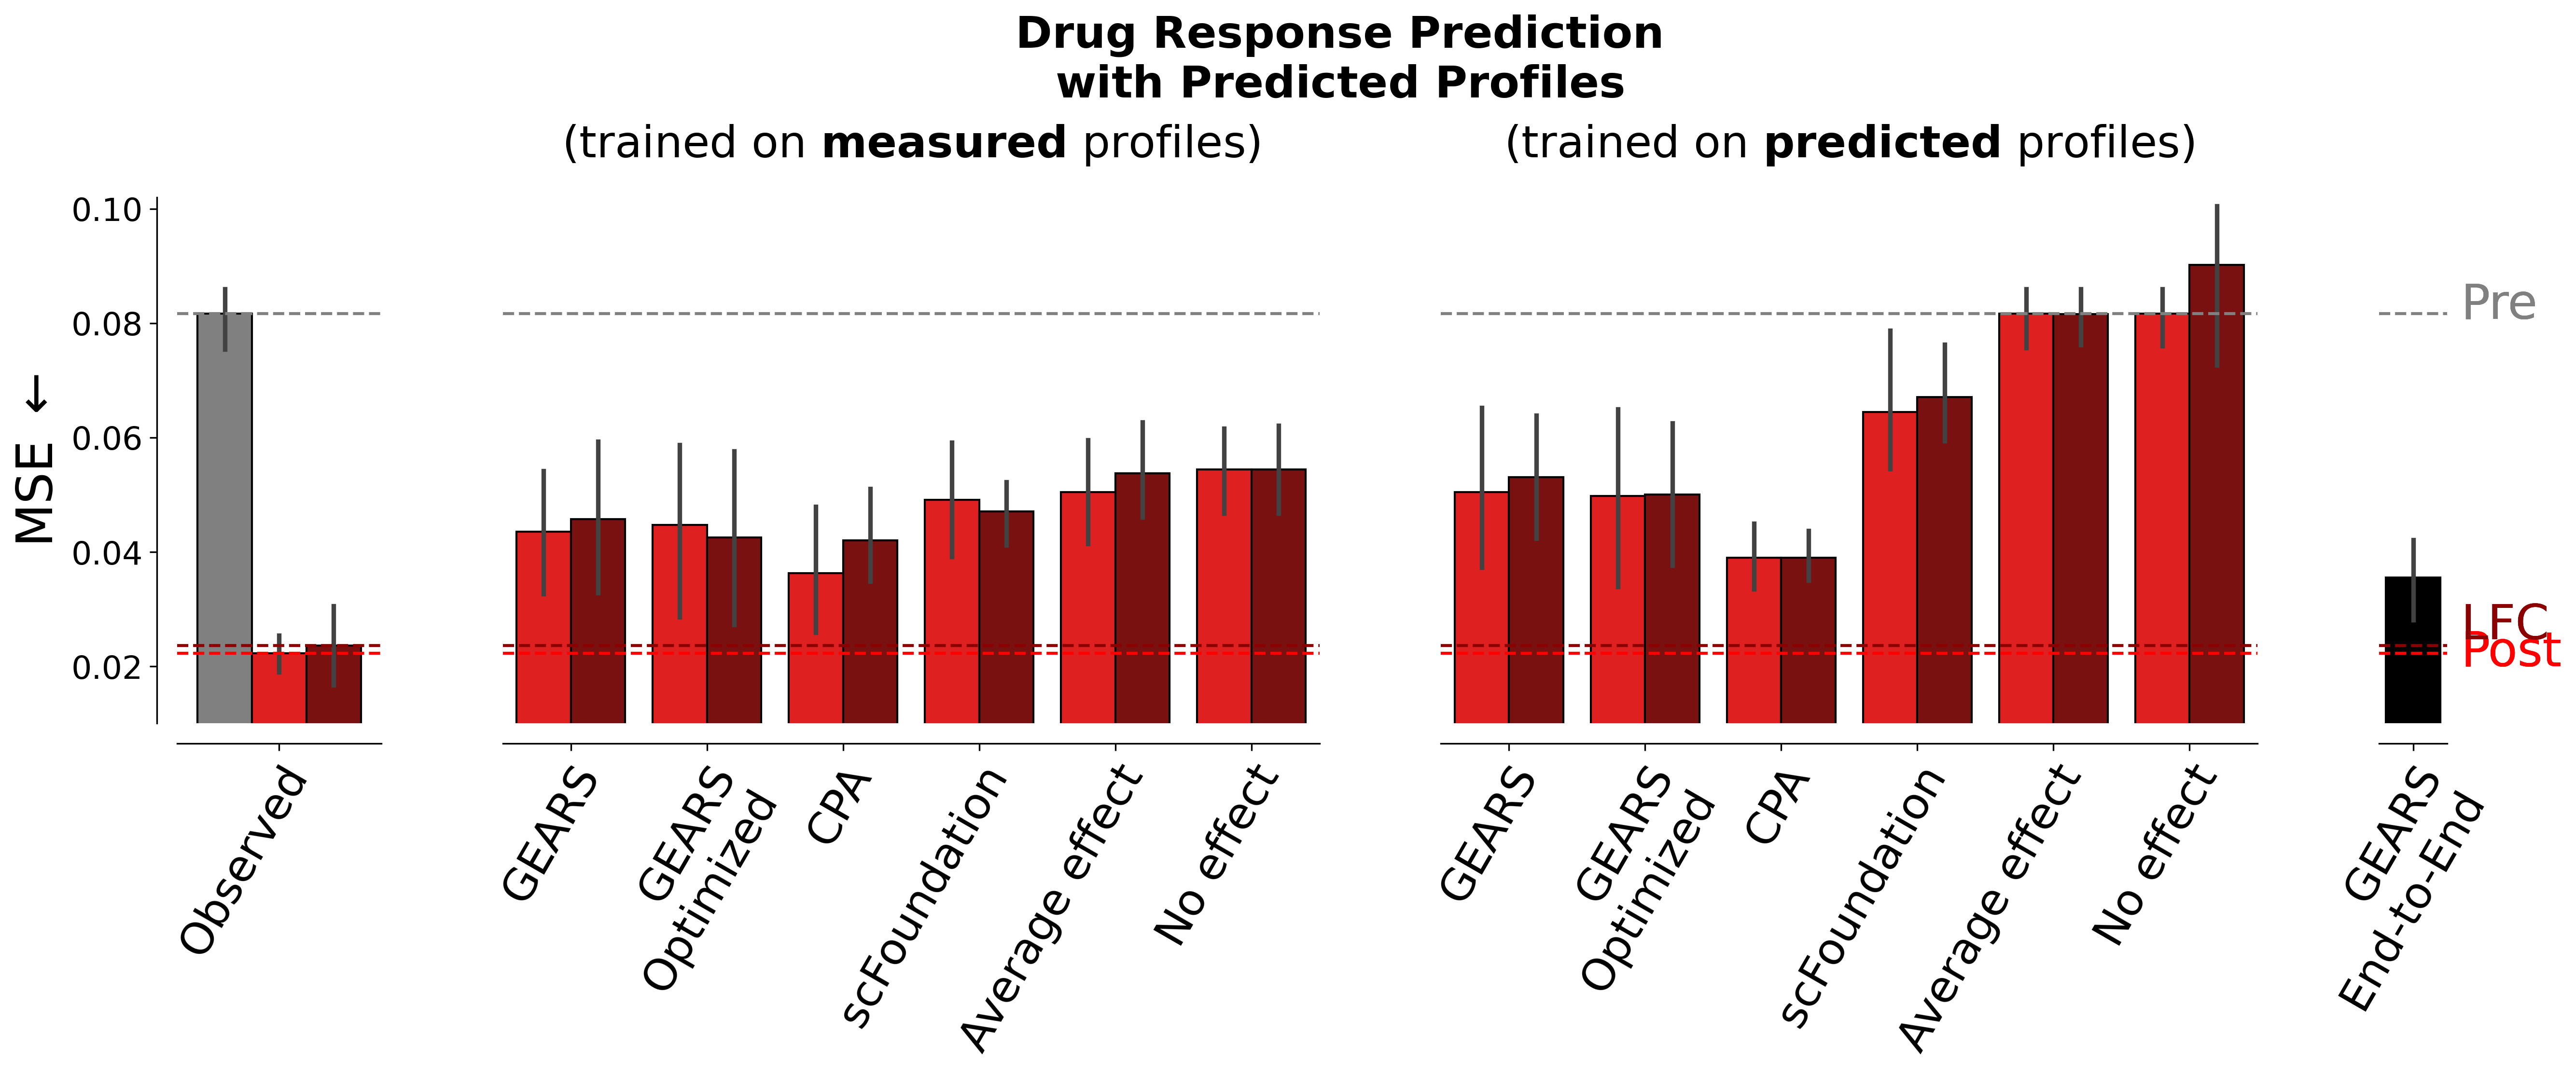

In [27]:
fig, ax= plot_sensitvity_predictions(sciplex_mse_results, metric='mse', plot_text=True, plot_end_to_end=True, plot_legend=False)
fig.savefig(os.path.join(figures_dir,'sciplex_predictions_with_predicted_profiles_mse.pdf'), bbox_inches='tight')
plt.show()

In [28]:
def top_k_overlap(pred, true, k=10):
    top_true = true.sort_values(ascending=False).head(k).index
    top_pred = pred.sort_values(ascending=False).head(k).index
    return len(set(top_true).intersection(top_pred)) / k

# Apply top-10 overlap per group
observedtrained_top10_results = (
    predictions_AUC.reset_index()  # ensure we can use the index for ranking
    .groupby(['model', 'test_set','train_set', 'split'])
    .apply(lambda g: pd.Series({
        'top10_overlap': top_k_overlap(g['pred'], g['true'])
    }))
    .reset_index()
)

selftrained_top10_results = (
    selftrained_predictions_AUC.reset_index()  # ensure we can use the index for ranking
    .groupby(['model', 'test_set','train_set', 'split'])
    .apply(lambda g: pd.Series({
        'top10_overlap': top_k_overlap(g['pred'], g['true'])
    }))
    .reset_index()
)

top10_results_endtoend = (
    end_to_end_predictions.reset_index()  # ensure we can use the index for ranking
    .groupby(['model', 'test_set','train_set', 'split'])
    .apply(lambda g: pd.Series({
        'top10_overlap': top_k_overlap(g['pred'], g['true'])
    }))
    .reset_index()
)

top10_results = pd.concat([observedtrained_top10_results.assign(trained_on='Observed'),selftrained_top10_results.assign(trained_on='Predicted'), top10_results_endtoend.assign(trained_on='End-to-end')], ignore_index=True)

top10_results['top10_overlap'] = top10_results['top10_overlap'] * 100  # Convert to percentage

top10_results = top10_results.replace({'post_treatment': 'Post', 'pre_treatment':'Pre'}).replace({'observed':'Observed',
                                                                                                                            'GEARS_noreg':'GEARS\nOptimized'})



C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_17188\2121672900.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_17188\2121672900.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_17188\2121672900.py:28: DeprecationWarning: DataFrameGroupBy.apply o

C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_17188\3105303686.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), fontsize=22, rotation=60, ha='right',rotation_mode='anchor')


Pre: 28.0, Post: 66.0, LFC: 68.0


C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_17188\3105303686.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), fontsize=22, rotation=60, ha='right',rotation_mode='anchor')
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_17188\3105303686.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), fontsize=22, rotation=60, ha='right',rotation_mode='anchor')
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_17188\3105303686.py:108: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[-1].set_xticklabels(['GEARS\nEnd-to-End'], fontsize=22, rotation=60, ha='right',rotation_mode='anchor')


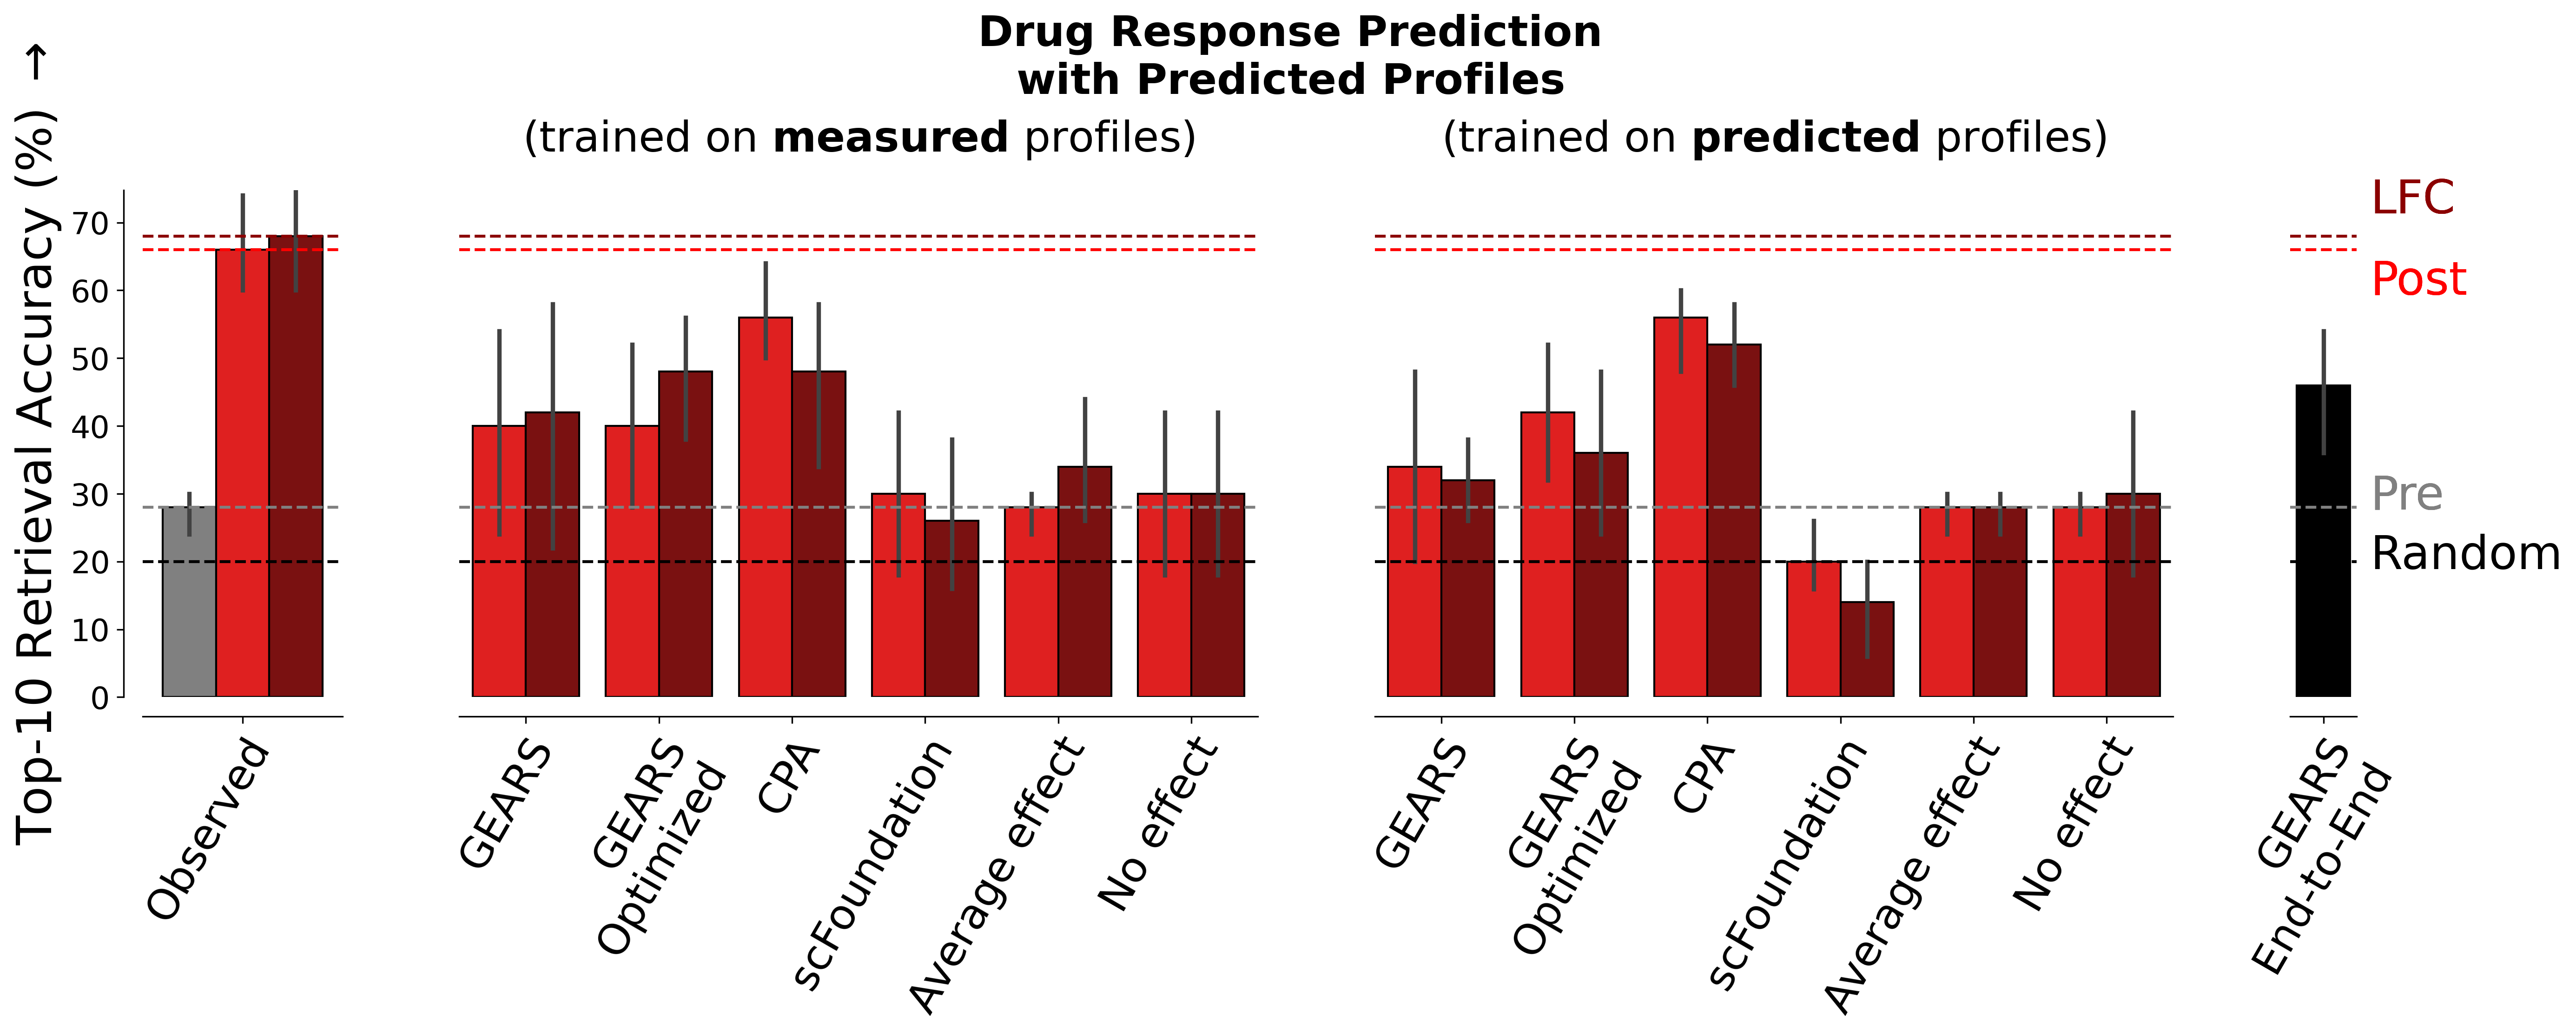

In [29]:
fig, ax = plot_sensitvity_predictions(top10_results, metric='top10_overlap', plot_text=True, plot_end_to_end=True, plot_legend=False)
ax[0].axhline(20, ls='--',color='black')
ax[1].axhline(20, ls='--',color='black')
ax[2].axhline(20, ls='--',color='black')
ax[3].axhline(20, ls='--',color='black')

ax[3].text(x=0.7, y=19, s='Random', color='black', fontsize=24, ha='left')
fig.savefig(os.path.join(figures_dir,'sciplex_predictions_with_predicted_profiles_retrieval_acc.pdf'), bbox_inches='tight')
plt.show()

Pre: 0.14920717063358385, Post: 0.7068229482147717, LFC: 0.7007283439750525


C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_17188\3841007303.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), fontsize=22, rotation=60, ha='right',rotation_mode='anchor')
C:\Users\nbrouwer1\AppData\Local\Temp\ipykernel_17188\3841007303.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), fontsize=22, rotation=60, ha='right',rotation_mode='anchor')


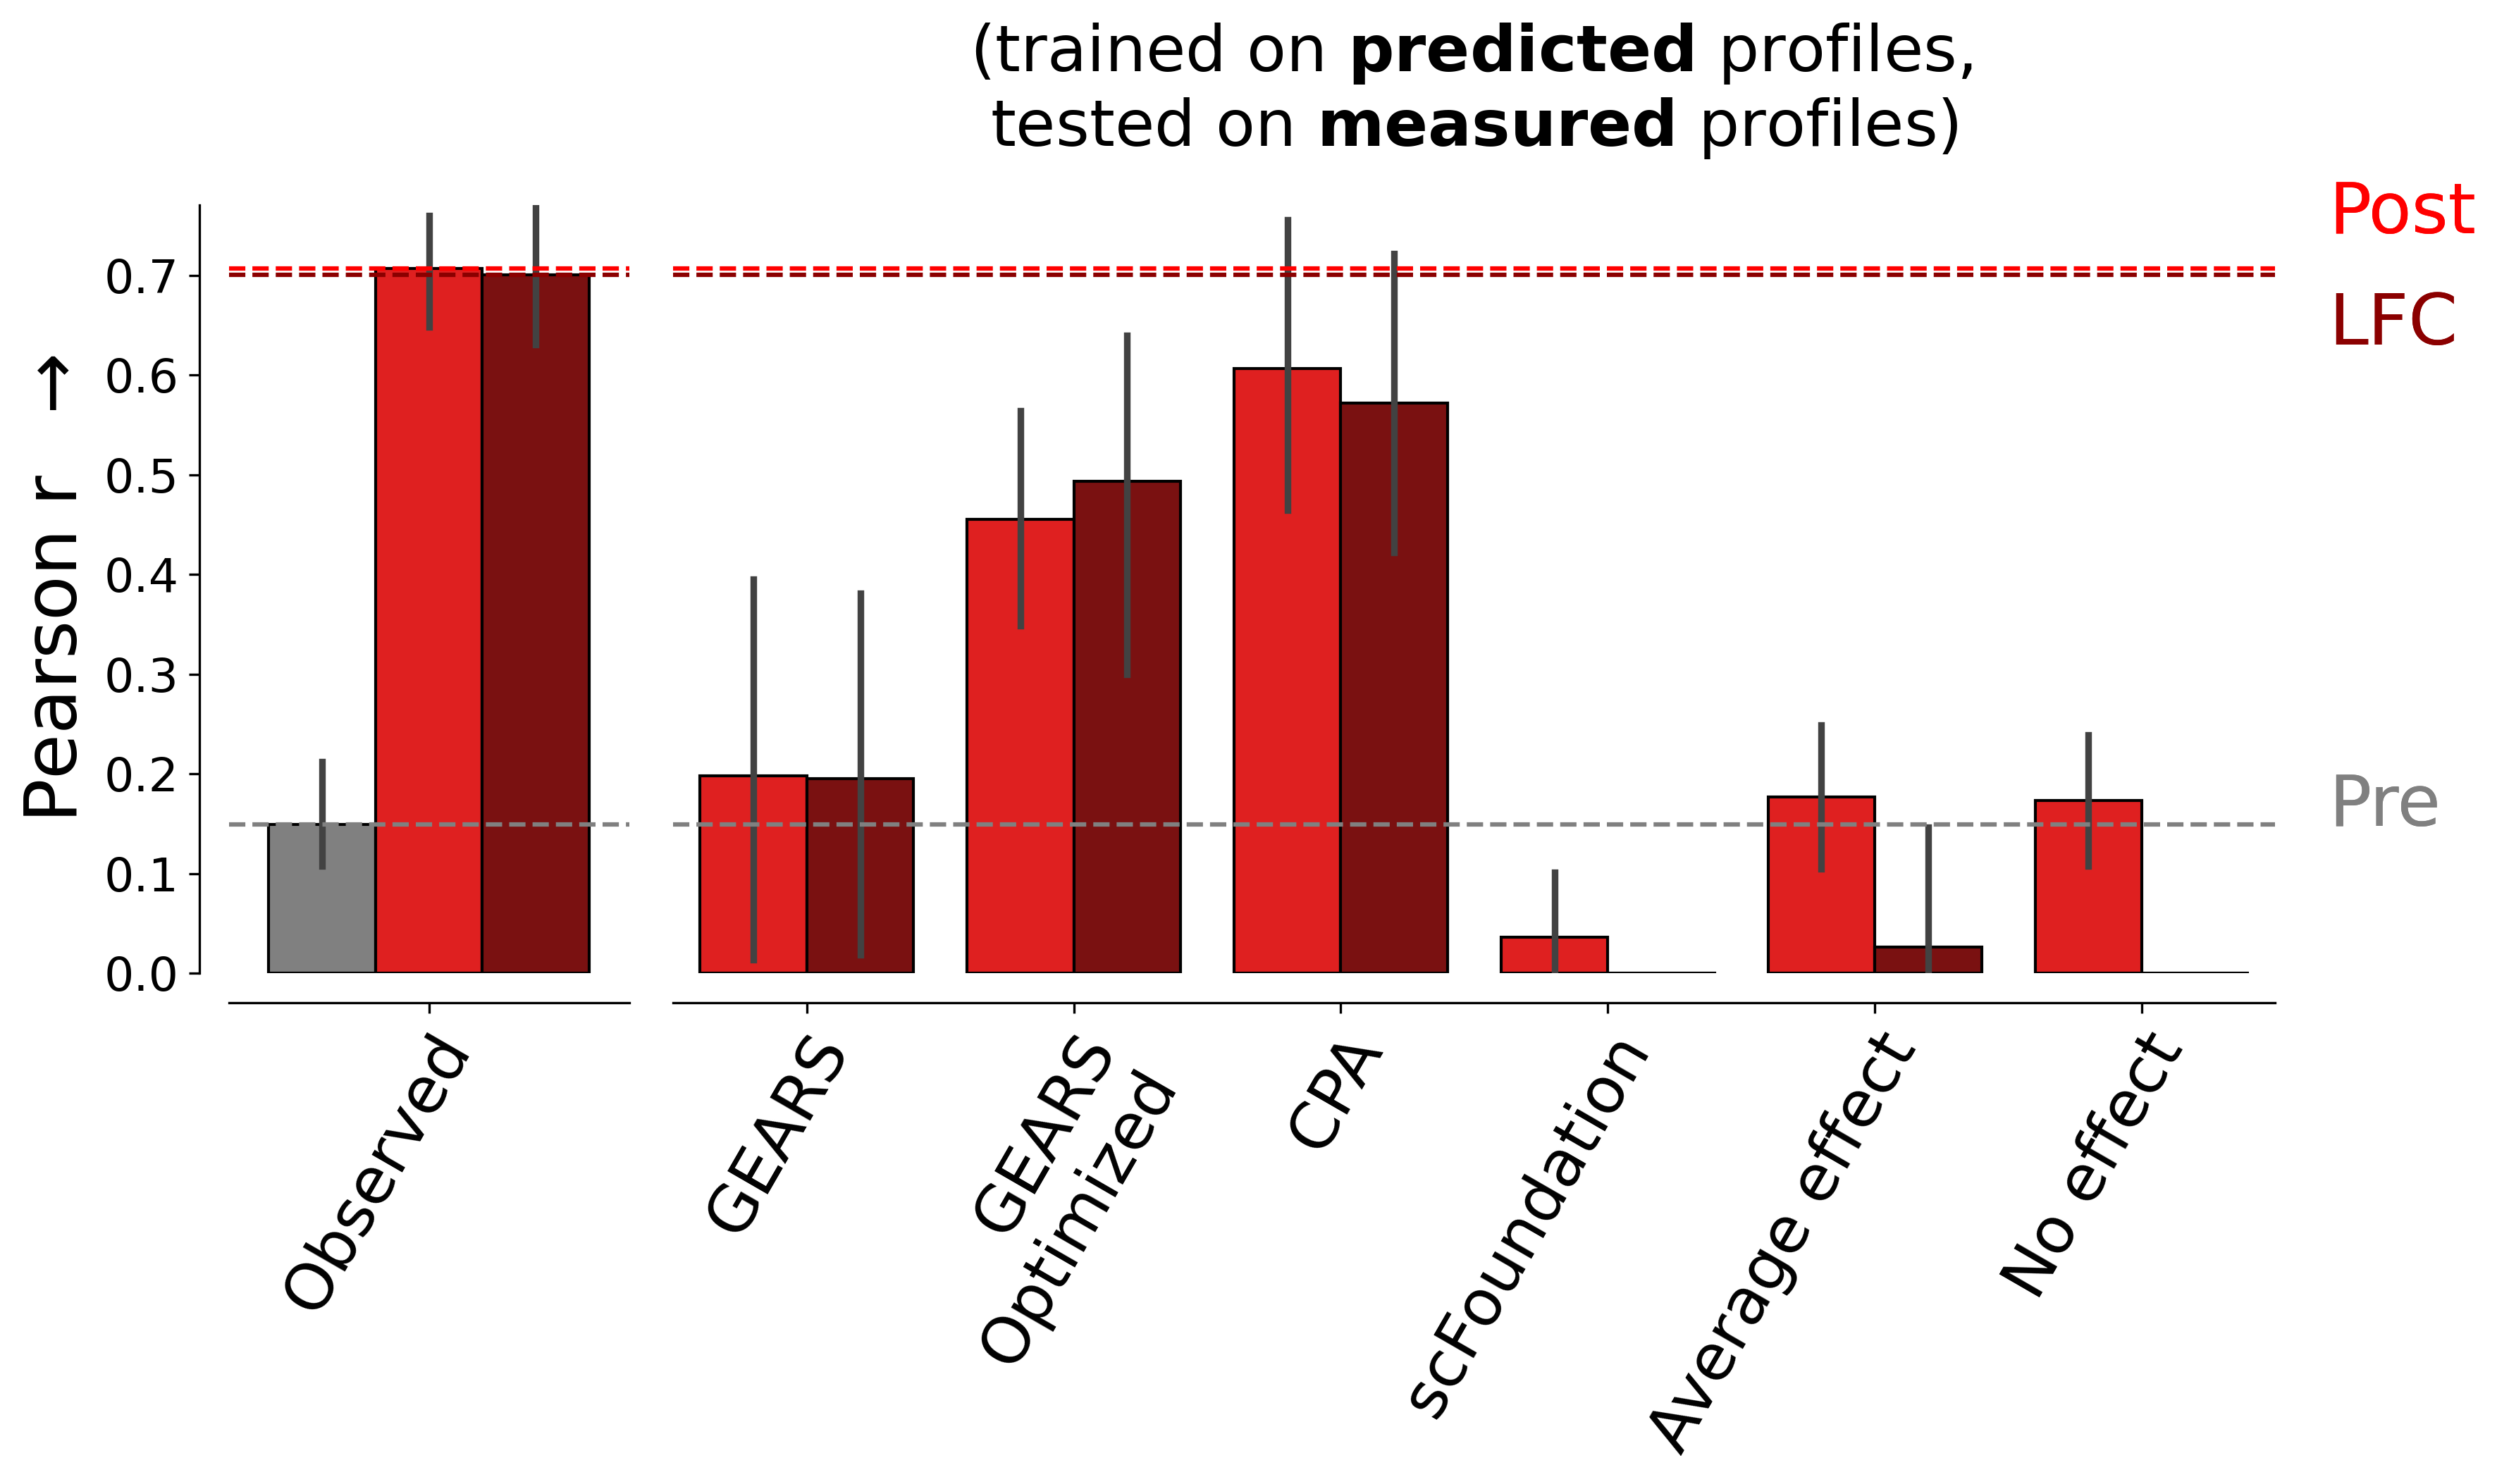

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 7), dpi=300, gridspec_kw={'width_ratios': [3,12]}, sharey=False)

# Calculate observed baselines
pre_observed = sciplex_pearson_results[(sciplex_pearson_results['trained_on'] == 'Observed')&(sciplex_pearson_results['test_set'] == 'Observed') & (sciplex_pearson_results['model'] == 'Pre')]['pearson'].mean()
post_observed = sciplex_pearson_results[(sciplex_pearson_results['trained_on'] == 'Observed')&(sciplex_pearson_results['test_set'] == 'Observed') & (sciplex_pearson_results['model'] == 'Post')]['pearson'].mean()
lfc_observed = sciplex_pearson_results[(sciplex_pearson_results['trained_on'] == 'Observed')&(sciplex_pearson_results['test_set'] == 'Observed') & (sciplex_pearson_results['model'] == 'LFC')]['pearson'].mean()
print(f'Pre: {pre_observed}, Post: {post_observed}, LFC: {lfc_observed}')

# --- LEFT SUBPLOT: bar_data ---
bar_data = sciplex_pearson_results[~sciplex_pearson_results['test_set'].isin(['GEARS\nEnd-to-End'])].copy()
bar0_data = bar_data[(bar_data['trained_on'] == 'Observed')&(bar_data['test_set'].isin(['Observed']))].copy()
bar3_data = bar_data[(bar_data['trained_on'] == 'Predicted')&(bar_data['test_set']=='Observed')].copy()

bar0_data['test_set'] = pd.Categorical(
    bar0_data['test_set'],
    categories=['Observed'],
    ordered=True
)
bar0_data['model'] = pd.Categorical(bar0_data['model'], categories=['Pre', 'Post', 'LFC'], ordered=True)

bar3_data['train_set'] = pd.Categorical(
    bar3_data['train_set'],
    categories=['GEARS', 'GEARS\nOptimized', 'CPA', 'scFoundation', 'Average effect', 'No effect'],
    ordered=True
)
bar3_data['model'] = pd.Categorical(bar3_data['model'], categories=['Post', 'LFC'], ordered=True)

bar_datasets = [bar0_data, bar3_data]

for i, bar_data in enumerate(bar_datasets):
    sns.barplot(
        data=bar_data,
        x='train_set' if i == 1 else 'test_set',
        hue='model',
        y='pearson',
        edgecolor='black',
        palette=[pre_post_lfc_palette[1], pre_post_lfc_palette[2]] if i > 0 else [pre_post_lfc_palette[0], pre_post_lfc_palette[1], pre_post_lfc_palette[2]] ,
        ax=axes[i]
    )

    sns.despine(ax=axes[i], offset=10, trim=False)
    
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), fontsize=22, rotation=60, ha='right',rotation_mode='anchor')
    axes[i].yaxis.set_tick_params(labelsize=16)

    axes[i].legend_.remove()

    axes[-1].text(x=5.7, y=pre_observed*0.99, s='Pre', color=pre_post_lfc_palette[0], fontsize=24, ha='left')
    if post_observed > lfc_observed:
        axes[-1].text(x=5.7, y=post_observed*1.05, s='Post', color=pre_post_lfc_palette[1], fontsize=24, ha='left')
        axes[-1].text(x=5.7, y=lfc_observed*0.9, s='LFC', color=pre_post_lfc_palette[2], fontsize=24, ha='left')
    else:
        axes[-1].text(x=5.7, y=post_observed*0.95, s='Post', color=pre_post_lfc_palette[1], fontsize=24, ha='left')
        axes[-1].text(x=5.7, y=lfc_observed*1, s='LFC', color=pre_post_lfc_palette[2], fontsize=24, ha='left')

for i, ax in enumerate(axes):
    axes[i].set_ylim(0,lfc_observed*1.1)
    axes[i].axhline(pre_observed, ls='--', color=pre_post_lfc_palette[0])
    axes[i].axhline(post_observed, ls='--', color=pre_post_lfc_palette[1])
    axes[i].axhline(lfc_observed, ls='--', color=pre_post_lfc_palette[2])
    if i > 0:
        axes[i].set_ylabel('')
        # Remove all y-axis elements
        axes[i].yaxis.set_visible(False)
        # Remove left spine (optional, depending on style)
        axes[i].spines['left'].set_visible(False)
        # Optional: tighter layout
        axes[i].tick_params(axis='y', which='both', left=False, labelleft=False)

metric_label = r'Pearson r  $\rightarrow$'

axes[0].set_ylabel(metric_label, fontsize=25)
import matplotlib as mpl
BR = r'\\' if mpl.rcParams['text.usetex'] else '\n'

# axes[0].set_title(fr"Trained on $\mathbf{{observed}}${BR}Tested on $\mathbf{{observed}}$", fontsize=18)

axes[1].set_title(fr"(trained on $\mathbf{{predicted}}$ profiles, {BR}tested on $\mathbf{{measured}}$ profiles)", fontsize=22, pad=20)
fig.tight_layout(pad=1.5)
fig.subplots_adjust(top=0.88)  # Make room for main title

fig.savefig(os.path.join(figures_dir,'sciplex_predictions_evaluation_on_measured.pdf'), bbox_inches='tight')